# Discrete Diffusion (LLaDA-style)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/winstonsmith1897/DantinoX/blob/main/docs/notebooks/02_discrete_diffusion.ipynb)

Covers:
- `Paradigm(ModelConfig(paradigm="discrete"))` — masking, (1/t)-weighted loss, reverse diffusion
- `noise_schedule`: `"linear"` · `"cosine"` · `"sqrt"`
- Bidirectional transformer (`causal=False` set automatically)
- Multiple attention variants with the discrete paradigm
- Text generation via iterative unmasking with four decoding strategies
- Block-wise generation (Fast-dLLM style) with optional DualCache
- `tokenizer.decode_display()` — visualise progressive unmasking with `▒` placeholders

**Runtime**: GPU (T4 or better)

In [1]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '6'

In [4]:
!pip install -q git+https://github.com/winstonsmith1897/DantinoX.git #egg=dantinox[all]

In [2]:
import os
import urllib.request

if not os.path.exists('tiny_shakespeare.txt'):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt',
        'tiny_shakespeare.txt')
    print('Downloaded tiny_shakespeare.txt')

## Basic Setup

`Paradigm(ModelConfig(paradigm="discrete"))` wraps a **bidirectional** transformer and owns:
- the forward masking process  
- the `(1/t)`-reweighted token-prediction loss  
- the reverse diffusion inference loop

`causal=False` is configured automatically when `paradigm="discrete"`.

In [3]:
import dantinox as dx

model_cfg = dx.ModelConfig(
    paradigm="discrete",     # sets causal=False automatically
    attention='mha',         # attention variant
    dim=256, n_heads=8, num_blocks=8,
    noise_schedule='cosine', # masking rate schedule
    weight_tying=False
    # mask_token_id is auto-detected from the tokenizer at training time
)
paradigm = dx.Paradigm(model_cfg)
print('Paradigm:', paradigm)

/home/marco.simoni/miniconda3/envs/dantinox/lib/python3.12/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.10.0 is installed, but it is not compatible with the installed jaxlib version 0.9.2, so it will not be used.
  warnings.warn(



  ████                █    █                █   █
  █   █  ███  ████  █████       ████   ███   █ █ 
  █   █ █   █ █   █   █    █    █   █ █   █   █  
  █   █ █  ██ █   █   █    █    █   █ █   █  █ █ 
  ████   ████ █   █   ██   ███  █   █  ███  █   █

  JAX/Flax transformer library  v0.4.0



Paradigm: Paradigm(type='discrete', impl=DiscreteParadigm(schedule='cosine', mask_id=-1))


In [4]:
run_dir = dx.Trainer(
    paradigm,
    dx.TrainingConfig(lr=3e-4, epochs=20, batch_size=16, tokenizer_type='bpe', optimizer='muon',
                       gradient_checkpointing=True),
).fit('tiny_shakespeare.txt')
print('Done:', run_dir)

E0706 12:03:13.862360 2027997 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 29.62GiB (31803604992 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0706 12:03:13.862873 2027997 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 26.66GiB (28623243264 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0706 12:03:13.863327 2027997 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 23.99GiB (25760917504 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0706 12:03:13.863777 2027997 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 21.59GiB (23184824320 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0706 12:03:13.864211 2027997 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 19.43GiB (20866340864 by


  ──────────────────────────────────────────────────────────────
  discrete  ·  bidirectional
  ──────────────────────────────────────────────────────────────
  run dir       runs/20260706_120312
  parameters    8.9 M  (8,926,440)

  ── model ─────────────────────────────────────────────────────
  256-dim  ·  8h×32  ·  8 blocks  ·  vocab=1,000  ·  ctx=512
  MHA  ·  RoPE  ·  RMSNorm  ·  bidirectional  ·  MLP(×4,SwiGLU)
  grad-ckpt

  ── data ──────────────────────────────────────────────────────
  source        tiny_shakespeare.txt
  tokenizer     bpe  ·  1000 vocab
  tokens        442,223  (train 398,001  ·  val 44,222)

  ── training ──────────────────────────────────────────────────
  optimizer     muon  ·  lr=3e-04  ·  cosine  ·  warmup=400
  batch         16
  schedule      20 epochs  ·  48 steps/epoch  ·  960 updates
  precision     fp32
  devices       1× GPU

  ──────────────────────────────────────────────────────────────



  step 1: JIT compiling (may take 1-3 min on first run)...


/home/marco.simoni/miniconda3/envs/dantinox/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1/20:   0%|          | 0/48 [00:00<?, ?it/s]

...

Epoch 20/20:  88%|████████▊ | 42/48 [00:01<00:00, 19.85it/s, loss=5.6045]

Epoch 20/20:  96%|█████████▌| 46/48 [00:01<00:00, 23.35it/s, loss=5.6045]

  Epoch 20/20  train=5.0882  val=4.9453  ★ best  2.1s



  ──────────────────────────────────────────────────────────────
  training complete  ·  best val loss = 4.9453
  saved → runs/20260706_120312
  ──────────────────────────────────────────────────────────────



Done: runs/20260706_120312


In [5]:
import os

import jax
import jax.numpy as jnp

from dantinox.utils.tokenizer import load_tokenizer_from_file

model     = dx.load(run_dir, paradigm=paradigm)
tokenizer = load_tokenizer_from_file(os.path.join(run_dir, 'tokenizer.json'))

prompt_text = 'HAMLET:\n'
prompt = jnp.array([tokenizer.encode(prompt_text)])

# decode_display shows ▒ for still-masked positions; pass mask_symbol=None to hide them
print('Iterative unmasking (sample, masks visible):')
for step, total, tokens in paradigm.stream(model, prompt, jax.random.PRNGKey(42),
                                            max_new_tokens=64, n_steps=50):
    text = tokenizer.decode_display(tokens[0].tolist())          # ▒ for masked
    print(f'\rStep {step+1:3d}/{total} │ {text}', end='', flush=True)
print()

Iterative unmasking (sample, masks visible):


Step   1/51 │ ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Step   2/51 │ ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Step   3/51 │ ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Step   4/51 │ ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒Ġst▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

...

Step  47/51 │ Ġheaven o : se JU ces Ġdis ing ct Ġsa MENENIUS ous ake Ċ JU Ġne ON EL 's RY Ċ igh Ġback Ġchild But AR Ġhea Ġknow UCES Ġst . Ġgra Ġwhen ce g Ċ Ġor Ċ ew uke hile ĠRome B ly AU z oy own Ċ EN , MEO ; est Ġno Ġhigh & , Ġthem S Ġtwo Ġwe Ġnot ĠYork

Step  48/51 │ Ġheaven o : se JU ces Ġdis ing ct Ġsa MENENIUS ous ake Ċ JU Ġne ON EL 's RY Ċ igh Ġback Ġchild But AR Ġhea Ġknow UCES Ġst . Ġgra Ġwhen ce g Ċ Ġor Ċ ew uke hile ĠRome B ly AU z oy own Ċ EN , MEO ; est Ġno Ġhigh & , Ġthem S Ġtwo Ġwe Ġnot ĠYork

Step  49/51 │ Ġheaven o : se JU ces Ġdis ing ct Ġsa MENENIUS ous ake Ċ JU Ġne ON EL 's RY Ċ igh Ġback Ġchild But AR Ġhea Ġknow UCES Ġst . Ġgra Ġwhen ce g Ċ Ġor Ċ ew uke hile ĠRome B ly AU z oy own Ċ EN , MEO ; est Ġno Ġhigh & , Ġthem S Ġtwo Ġwe Ġnot ĠYork

Step  50/51 │ Ġheaven o : se JU ces Ġdis ing ct Ġsa MENENIUS ous ake Ċ JU Ġne ON EL 's RY Ċ igh Ġback Ġchild But AR Ġhea Ġknow UCES Ġst . Ġgra Ġwhen ce g Ċ Ġor Ċ ew uke hile ĠRome B ly AU z oy own Ċ EN , MEO ; est Ġno Ġhigh & , Ġthem S Ġtwo Ġwe Ġnot ĠYork

Step  51/51 │ Ġheaven o : se JU ces Ġdis ing ct Ġsa MENENIUS ous ake Ċ JU Ġne ON EL 's RY Ċ igh Ġback Ġchild But AR Ġhea Ġknow UCES Ġst . Ġgra Ġwhen ce g Ċ Ġor Ċ ew uke hile ĠRome B ly AU z oy own Ċ EN , MEO ; est Ġno Ġhigh & , Ġthem S Ġtwo Ġwe Ġnot ĠYork

## Decoding Strategies

`paradigm.stream()` and `paradigm.generate()` support four `decoding_strategy` options:

| Strategy | Description | Best for |
|---|---|---|
| `"sample"` | Temperature-scaled categorical sampling (default) | Diverse, creative output |
| `"greedy"` | Argmax at each step — deterministic | Reproducible, coherent output |
| `"confidence"` | Unmask positions with softmax confidence ≥ `confidence_threshold` | Faster convergence |
| `"factor"` | Fast-dLLM factor-based unmasking (Thm. 1) | Theoretically grounded parallel decoding |

`decode_display(tokens, mask_symbol=None)` hides masked positions instead of showing `▒`.

In [6]:
strategies = [
    ('greedy',     dict(decoding_strategy='greedy')),
    ('confidence', dict(decoding_strategy='confidence', confidence_threshold=0.85)),
    ('factor',     dict(decoding_strategy='factor',     factor=1.5)),
]

for name, kwargs in strategies:
    *_, (_, _, tokens) = paradigm.stream(model, prompt, jax.random.PRNGKey(42),
                                          max_new_tokens=64, n_steps=30, **kwargs)
    text = tokenizer.decode_display(tokens[0].tolist(), mask_symbol=None)
    print(f'{name:12s} │ {text}')

greedy       │ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ Ċ : Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ : Ċ : Ċ Ċ Ċ Ċ Ċ Ċ : : Ċ Ċ : Ċ : Ċ : Ċ Ċ Ċ Ċ : Ċ Ċ :


confidence   │ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ Ċ : Ċ Ċ Ċ Ċ : : Ċ Ċ Ċ Ċ Ċ : : Ċ Ċ Ċ Ċ Ċ


factor       │ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ Ċ : Ċ Ċ Ċ Ċ : : Ċ Ċ Ċ Ċ Ċ : : Ċ Ċ Ċ Ċ Ċ


## Block-wise Generation (Fast-dLLM style)

Pass `block_size` to both `stream()` and `generate()` to switch to block-wise generation.  
Tokens are decoded one block at a time — each block is fully revealed before the next starts.

| Parameter | Default | Description |
|---|---|---|
| `block_size` | `None` (global) | Tokens per block; set to activate block mode |
| `steps_per_block` | `50` | Inner denoising steps per block |
| `use_dual_cache` | `True` | Prefix+suffix DualCache (requires model to implement `decode_block`) |

`use_dual_cache=False` works with any trained model and is useful for ablations.

In [7]:
# Block-wise streaming without dual cache — works with any trained model
print('Block-wise unmasking (block_size=16, no dual cache):')
for step, total, tokens in paradigm.stream(model, prompt, jax.random.PRNGKey(42),
                                            max_new_tokens=64, n_steps=50,
                                            block_size=16, steps_per_block=30,
                                            use_dual_cache=False):
    text = tokenizer.decode_display(tokens[0].tolist())
    print(f'\rStep {step+1:3d}/{total} │ {text}', end='', flush=True)
print()

# Non-streaming: just get the final tokens
tokens = paradigm.generate(model, prompt, jax.random.PRNGKey(42),
                            max_new_tokens=64,
                            block_size=16, steps_per_block=30,
                            use_dual_cache=False)
print('generate() result:', tokenizer.decode(tokens[0].tolist()))

Block-wise unmasking (block_size=16, no dual cache):


Step   1/125 │ Ċ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Step   2/125 │ Ċ▒▒▒▒▒Ċ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Step   3/125 │ Ċ▒▒▒▒▒Ċ Ċ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Step   4/125 │ Ċ Ċ▒▒▒▒Ċ Ċ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

...

Step  62/125 │ Ċ Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : Ċ : Ċ Ċ : Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ : Ċ : Ċ Ċ Ċ Ċ Ċ▒▒Ċ : Ċ Ċ Ċ

Step  63/125 │ Ċ Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : Ċ : Ċ Ċ : Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ : Ċ : Ċ Ċ Ċ Ċ Ċ :▒Ċ : Ċ Ċ Ċ

Step  64/125 │ Ċ Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : Ċ : Ċ Ċ : Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ : Ċ : Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ Ċ Ċ

Step  65/125 │ Ċ Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : Ċ : Ċ Ċ : Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ : Ċ : Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ Ċ Ċ

generate() result: Ċ Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : Ċ Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : Ċ : Ċ Ċ : Ċ Ċ : Ċ Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ : Ċ : Ċ Ċ Ċ Ċ Ċ : Ċ Ċ : Ċ Ċ Ċ


In [8]:
# Block-wise with DualCache — requires model to support compute_block_dual_cache / decode_block
# (available on DiffusionTransformer models from production runs)
print('Block-wise unmasking (block_size=16, dual cache):')
for step, total, tokens in paradigm.stream(model, prompt, jax.random.PRNGKey(42),
                                            max_new_tokens=64,
                                            block_size=16, steps_per_block=30,
                                            use_dual_cache=True):     # default
    text = tokenizer.decode_display(tokens[0].tolist())
    print(f'\rStep {step+1:3d}/{total} │ {text}', end='', flush=True)
print()

Block-wise unmasking (block_size=16, dual cache):


Step   1/125 │ ▒▒▒▒▒▒Ċ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Step   2/125 │ ▒▒▒▒▒▒Ċ Ċ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Step   3/125 │ ▒▒▒▒▒Ċ Ċ Ċ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Step   4/125 │ ▒▒▒▒▒Ċ Ċ Ċ Ċ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

...

Step  61/125 │ Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ :▒▒Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : :▒: :

Step  62/125 │ Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ :▒▒Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : : :

Step  63/125 │ Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : :▒Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : : :

Step  64/125 │ Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : : :

Step  65/125 │ Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : Ċ Ċ Ċ Ċ Ċ Ċ Ċ Ċ : : : : : :

## Noise Schedule Comparison

The noise schedule controls how aggressively tokens are masked as `t → 1`.

| Schedule | `p_mask(t)` | Character |
|---|---|---|
| `linear` | `t` | Uniform masking rate |
| `cosine` | `1 − cos(πt/2)` | Slow start, fast finish |
| `sqrt` | `√t` | Fast start, slow finish |

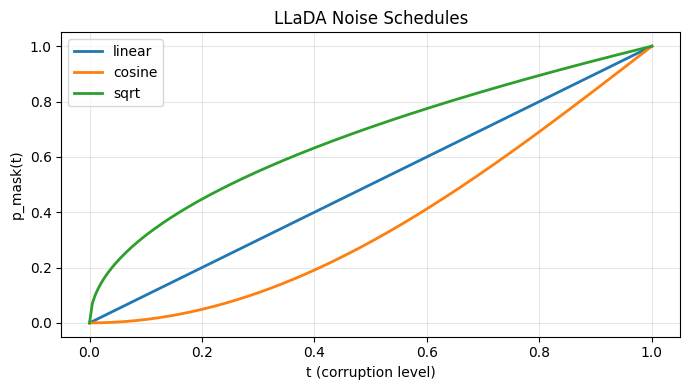

In [9]:
import matplotlib.pyplot as plt
import numpy as np

t = np.linspace(0, 1, 200)
schedules = {'linear': t, 'cosine': 1 - np.cos(np.pi * t / 2), 'sqrt': np.sqrt(t)}

fig, ax = plt.subplots(figsize=(7, 4))
for name, p in schedules.items():
    ax.plot(t, p, label=name, linewidth=2)
ax.set_xlabel('t (corruption level)')
ax.set_ylabel('p_mask(t)')
ax.set_title('LLaDA Noise Schedules')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# Train with each noise schedule and compare loss
schedule_runs = {}
for sched in ('linear', 'cosine', 'sqrt'):
    p  = dx.Paradigm(
        dx.ModelConfig(paradigm="discrete", dim=128, n_heads=2, num_blocks=2,
                       noise_schedule=sched),
    )
    rd = dx.Trainer(p, dx.TrainingConfig(lr=3e-4, epochs=1, batch_size=16, tokenizer_type='bpe')).fit(
        'tiny_shakespeare.txt', run_dir=f'/tmp/dx_disc_{sched}')
    schedule_runs[sched] = rd
    print(f'{sched}: done → {rd}')


  ──────────────────────────────────────────────────────────────
  discrete  ·  bidirectional
  ──────────────────────────────────────────────────────────────
  run dir       /tmp/dx_disc_linear
  parameters    0.7 M  (655,488)

  ── model ─────────────────────────────────────────────────────
  128-dim  ·  2h×64  ·  2 blocks  ·  vocab=1,000  ·  ctx=512
  MHA  ·  RoPE  ·  RMSNorm  ·  bidirectional  ·  MLP(×4,SwiGLU)

  ── data ──────────────────────────────────────────────────────
  source        tiny_shakespeare.txt
  tokenizer     bpe  ·  1000 vocab
  tokens        442,223  (train 398,001  ·  val 44,222)

  ── training ──────────────────────────────────────────────────
  optimizer     adamw  ·  lr=3e-04  ·  cosine  ·  warmup=400
  batch         16
  schedule      1 epoch  ·  48 steps/epoch  ·  48 updates
  precision     fp32
  devices       1× GPU

  ──────────────────────────────────────────────────────────────



  step 1: JIT compiling (may take 1-3 min on first run)...


Epoch 1/1:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 1/1:   0%|          | 0/48 [00:14<?, ?it/s, loss=7.4514]

Epoch 1/1:   2%|▏         | 1/48 [00:14<11:15, 14.37s/it, loss=7.4514]

...

Epoch 1/1:  69%|██████▉   | 33/48 [00:11<00:03,  4.79it/s, loss=18.3028]

Epoch 1/1:  69%|██████▉   | 33/48 [00:11<00:03,  4.79it/s, loss=9.1304] 

  Epoch 1/1  train=12.6414  val=12.4091  ★ best  11.7s



  ──────────────────────────────────────────────────────────────
  training complete  ·  best val loss = 12.4091
  saved → /tmp/dx_disc_sqrt
  ──────────────────────────────────────────────────────────────



sqrt: done → /tmp/dx_disc_sqrt


## Attention Variants with Discrete Paradigm

The diffusion model's `Transformer` supports the same attention options as the AR one.

In [11]:
from flax import nnx


def disc_param_count(model_cfg):
    p = dx.Paradigm(model_cfg)
    m = p.build_model(nnx.Rngs(0))
    return sum(x.size for x in jax.tree_util.tree_leaves(nnx.state(m, nnx.Param)))

disc_attn_cfgs = [
    ('MHA',            dx.ModelConfig(paradigm="discrete", dim=256, n_heads=4, num_blocks=4,
                                      vocab_size=200, attention='mha')),
    ('GQA kv_heads=2', dx.ModelConfig(paradigm="discrete", dim=256, n_heads=4, num_blocks=4,
                                      vocab_size=200, attention='gqa', kv_heads=2)),
    ('MLA',            dx.ModelConfig(paradigm="discrete", dim=256, n_heads=4, num_blocks=4,
                                      vocab_size=200, attention='mla')),
]

for name, cfg in disc_attn_cfgs:
    n = disc_param_count(cfg)
    print(f'{name:20s}  {n/1e6:.2f}M params')

MHA                   4.26M params


GQA kv_heads=2        4.00M params


MLA                   4.86M params


In [12]:
# Train the discrete model with GQA
gqa_disc = dx.Paradigm(
    dx.ModelConfig(paradigm="discrete", dim=256, n_heads=4, num_blocks=4,
                   attention='gqa', kv_heads=2,
                   noise_schedule='cosine'),
)
gqa_disc_run = dx.Trainer(
    gqa_disc,
    dx.TrainingConfig(lr=3e-4, epochs=1, batch_size=16),
).fit('tiny_shakespeare.txt', run_dir='/tmp/dx_disc_gqa')
print('GQA discrete run:', gqa_disc_run)


  ──────────────────────────────────────────────────────────────
  discrete  ·  bidirectional
  ──────────────────────────────────────────────────────────────
  run dir       /tmp/dx_disc_gqa
  parameters    4.0 M  (3,961,344)

  ── model ─────────────────────────────────────────────────────
  256-dim  ·  4h×64  ·  4 blocks  ·  vocab=65  ·  ctx=512
  GQA(4q/2kv)  ·  RoPE  ·  RMSNorm  ·  bidirectional  ·  MLP(×4,SwiGLU)

  ── data ──────────────────────────────────────────────────────
  source        tiny_shakespeare.txt
  tokenizer     char  ·  65 vocab
  tokens        1,115,394  (train 1,003,855  ·  val 111,539)

  ── training ──────────────────────────────────────────────────
  optimizer     adamw  ·  lr=3e-04  ·  cosine  ·  warmup=400
  batch         16
  schedule      1 epoch  ·  122 steps/epoch  ·  122 updates
  precision     fp32
  devices       1× GPU

  ──────────────────────────────────────────────────────────────



  step 1: JIT compiling (may take 1-3 min on first run)...


Epoch 1/1:   0%|          | 0/122 [00:00<?, ?it/s]

Epoch 1/1:   0%|          | 0/122 [00:13<?, ?it/s, loss=3.7652]

Epoch 1/1:   1%|          | 1/122 [00:13<27:12, 13.49s/it, loss=3.7652]

...

Epoch 1/1:  93%|█████████▎| 113/122 [00:14<00:00, 51.35it/s, loss=3.0222]

Epoch 1/1:  93%|█████████▎| 113/122 [00:15<00:00, 51.35it/s, loss=3.2751]

  Epoch 1/1  train=2.8482  val=2.7505  ★ best  15.1s



  ──────────────────────────────────────────────────────────────
  training complete  ·  best val loss = 2.7505
  saved → /tmp/dx_disc_gqa
  ──────────────────────────────────────────────────────────────



GQA discrete run: /tmp/dx_disc_gqa


## One-liner Discrete Training

`dx.fit('discrete', ...)` is the shortest path to a discrete diffusion checkpoint.

In [13]:
rd = dx.fit(
    'discrete', 'tiny_shakespeare.txt',
    dim=256, n_heads=4, head_size=64, num_blocks=4,
    noise_schedule='cosine',
    lr=3e-4, epochs=2, batch_size=16,
)
print('Discrete run dir:', rd)


  ──────────────────────────────────────────────────────────────
  discrete  ·  bidirectional
  ──────────────────────────────────────────────────────────────
  run dir       runs/20260706_120707
  parameters    4.2 M  (4,223,488)

  ── model ─────────────────────────────────────────────────────
  256-dim  ·  4h×64  ·  4 blocks  ·  vocab=65  ·  ctx=512
  MHA  ·  RoPE  ·  RMSNorm  ·  bidirectional  ·  MLP(×4,SwiGLU)

  ── data ──────────────────────────────────────────────────────
  source        tiny_shakespeare.txt
  tokenizer     char  ·  65 vocab
  tokens        1,115,394  (train 1,003,855  ·  val 111,539)

  ── training ──────────────────────────────────────────────────
  optimizer     adamw  ·  lr=3e-04  ·  cosine  ·  warmup=400
  batch         16
  schedule      2 epochs  ·  122 steps/epoch  ·  244 updates
  precision     fp32
  devices       1× GPU

  ──────────────────────────────────────────────────────────────



  step 1: JIT compiling (may take 1-3 min on first run)...


Epoch 1/2:   0%|          | 0/122 [00:00<?, ?it/s]

Epoch 1/2:   0%|          | 0/122 [00:13<?, ?it/s, loss=3.9321]

Epoch 1/2:   1%|          | 1/122 [00:13<27:42, 13.74s/it, loss=3.9321]

...

Epoch 2/2:  93%|█████████▎| 113/122 [00:01<00:00, 88.50it/s, loss=2.8322]

Epoch 2/2: 100%|██████████| 122/122 [00:01<00:00, 87.57it/s, loss=2.8322]

  Epoch 2/2  train=2.6603  val=2.5837  ★ best  1.4s



  ──────────────────────────────────────────────────────────────
  training complete  ·  best val loss = 2.5837
  saved → runs/20260706_120707
  ──────────────────────────────────────────────────────────────



Discrete run dir: runs/20260706_120707


## FFN Variants with Discrete Paradigm

In [14]:
ffn_cfgs = [
    ('SwiGLU MLP',    dx.ModelConfig(paradigm="discrete", dim=256, n_heads=4, head_size=64, num_blocks=4,
                                     vocab_size=200, ffn='mlp')),
    ('GELU MLP',      dx.ModelConfig(paradigm="discrete", dim=256, n_heads=4, head_size=64, num_blocks=4,
                                     vocab_size=200, ffn='mlp', use_swiglu=False)),
    ('MoE 4 experts', dx.ModelConfig(paradigm="discrete", dim=256, n_heads=4, head_size=64, num_blocks=4,
                                     vocab_size=200, ffn='moe', n_experts=4, top_k=2)),
    ('MoE 8 Latent experts', dx.ModelConfig(paradigm="discrete", dim=256, n_heads=4, head_size=64, num_blocks=4,
                                     vocab_size=200, ffn='moe', n_experts=8, moe_latent=True, moe_latent_dim=64, top_k=2)),
]

for name, cfg in ffn_cfgs:
    n = disc_param_count(cfg)
    print(f'{name:20s}  {n/1e6:.2f}M params')

SwiGLU MLP            4.26M params


GELU MLP              3.21M params


MoE 4 experts         13.73M params


MoE 8 Latent experts  7.60M params
